# Setup

In [1]:
# Libs
import phobos
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def save_data(path, filename, data):
    np.save(path / filename, data)
    print('Data saved in', path / filename)

✅ BMC lib found. Running in control mode.


In [ ]:
# shortcuts
dm = phobos.DM()
cam = phobos.Cred3()
inj_seg = phobos.Config().get('injection.segments')
print('Injected segments:', inj_seg)

# Setup
path = phobos.archive.new('spectral_calibration', verbose=True)


DEBUG - SDK Install Path: /opt/Boston Micromachines
DEBUG - BMC_PCIeOpenDM 27BW007#051 0
DEBUG - 1 BMC PCIe cards installed.
DEBUG - Using automatic devId: 1
DEBUG - BMC_PCIeOpenDM opening 0
INFO - PCIe HW Rev: 20000502
DEBUG - Loading map file: /opt/Boston Micromachines/Map/KILO507.map expected count: 1024
INFO - Loading calibration for DM: 27BW07#051_5_3_setof14
DEBUG - Loading map file: /opt/Boston Micromachines/Map/KILO507.map expected count: 1024
Cred3 camera initialized with dark subtraction
Injected segments: [138, 137, 136, 135]
Archive created at /mnt/disk1/archive/2026-06-10_5ad8eba/4_spectral_calibration


# Check cropping

✅ Cred3 reset to configuration defaults.


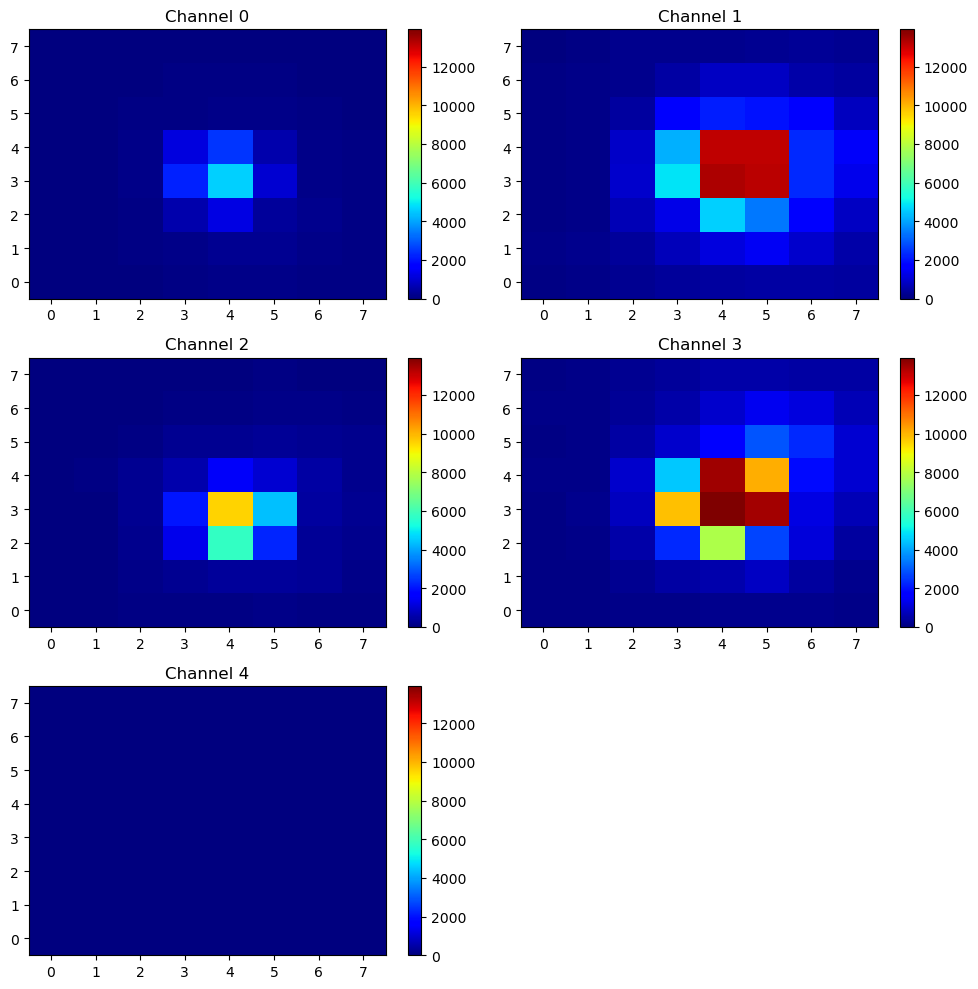

In [3]:
# check cropping
phobos.Config().reload()
cam.reset()
cam.check_cropping(crop_mode='centers')

# Calibration injection

In [4]:
# Injection calibration
inj = phobos.Injection()


In [1]:
# inj.zero()
# maps = inj.get_injection_maps(verbose=True)
# inj.zero()

# fig = plt.figure(figsize=(10,10))
# for i in range(4):
#     image = maps[0][i]
#     tip_range = tilt_ramp = maps[1]
#     tilt_step = np.diff(tilt_ramp)[0]
#     tip_step = np.diff(tip_range)[0]
#     plt.subplot(2,2,i+1)
#     plt.imshow(image, origin='lower', cmap='jet',
#             extent=[tilt_ramp.min()-tilt_step/2, tilt_ramp.max()+tilt_step/2,
#                     tip_range.min()-tip_step/2, tip_range.max()+tip_step/2],
#             vmin=maps[0].min(),
#             vmax=maps[0].max())
#     plt.colorbar()
#     plt.xlabel('Tilt (mrad)')
#     plt.ylabel('Tip (mrad)')
# plt.tight_layout()

Scanning injection maps:   0%|          | 0/4 [00:00<?, ?it/s]

  Channel 0 (segment 138): scanning…
Injection OFF on channels [1, 2, 3] (segments [137, 136, 135])


Scanning injection maps:  25%|██▌       | 1/4 [00:13<00:41, 13.84s/it]

Injection OFF on channels [0] (segments [138])
  Channel 1 (segment 137): scanning…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])


Scanning injection maps:  50%|█████     | 2/4 [00:28<00:28, 14.34s/it]

...

Scanning injection maps:  75%|███████▌  | 3/4 [00:47<00:16, 16.25s/it]

Injection OFF on channels [2] (segments [136])
  Channel 3 (segment 135): scanning…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])


Scanning injection maps: 100%|██████████| 4/4 [01:05<00:00, 16.41s/it]

Injection OFF on channels [3] (segments [135])
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])

── Find gross TT for max injection and spread ──
Injection spread of seg=138: (tip, tilt) = (0.69631,0.76513) mrad
Injection spread of seg=137: (tip, tilt) = (0.72186,0.79413) mrad
Injection spread of seg=136: (tip, tilt) = (0.78445,0.71157) mrad
Injection spread of seg=135: (tip, tilt) = (0.73433,0.82477) mrad

── Find precise TT for max injection ──
Injection max of seg=138: (tip, tilt) = (-0.28843,0.18626) mrad; flux = 1678
Injection max of seg=137: (tip, tilt) = (0.00437,0.09682) mrad; flux = 1651
Injection max of seg=136: (tip, tilt) = (0.36578,-0.01765) mrad; flux = 1460
Injection max of seg=135: (tip, tilt) = (0.55823,0.03760) mrad; flux = 1665
✅ Injection calibration saved to config (injection.max)



── Finding maximum injection points ──

── Balancing injection fluxes ──
  Weakest channel: 2 (seg 136), target flux = 1394
  Dichotomy on channel 0 (seg 138)…
Injection OFF on channels [1, 2, 3] (segments [137, 136, 135])
    → balanced tilt = 0.5355 mrad, flux = 1381 (target 1394), iterations = 13
  Dichotomy on channel 1 (seg 137)…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])
    → balanced tilt = 0.3646 mrad, flux = 1396 (target 1394), iterations = 13
  Dichotomy on channel 3 (seg 135)…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])
    → balanced tilt = 0.3287 mrad, flux = 1390 (target 1394), iterations = 13
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
✅ Injection calibration saved to config (injection.balanced)


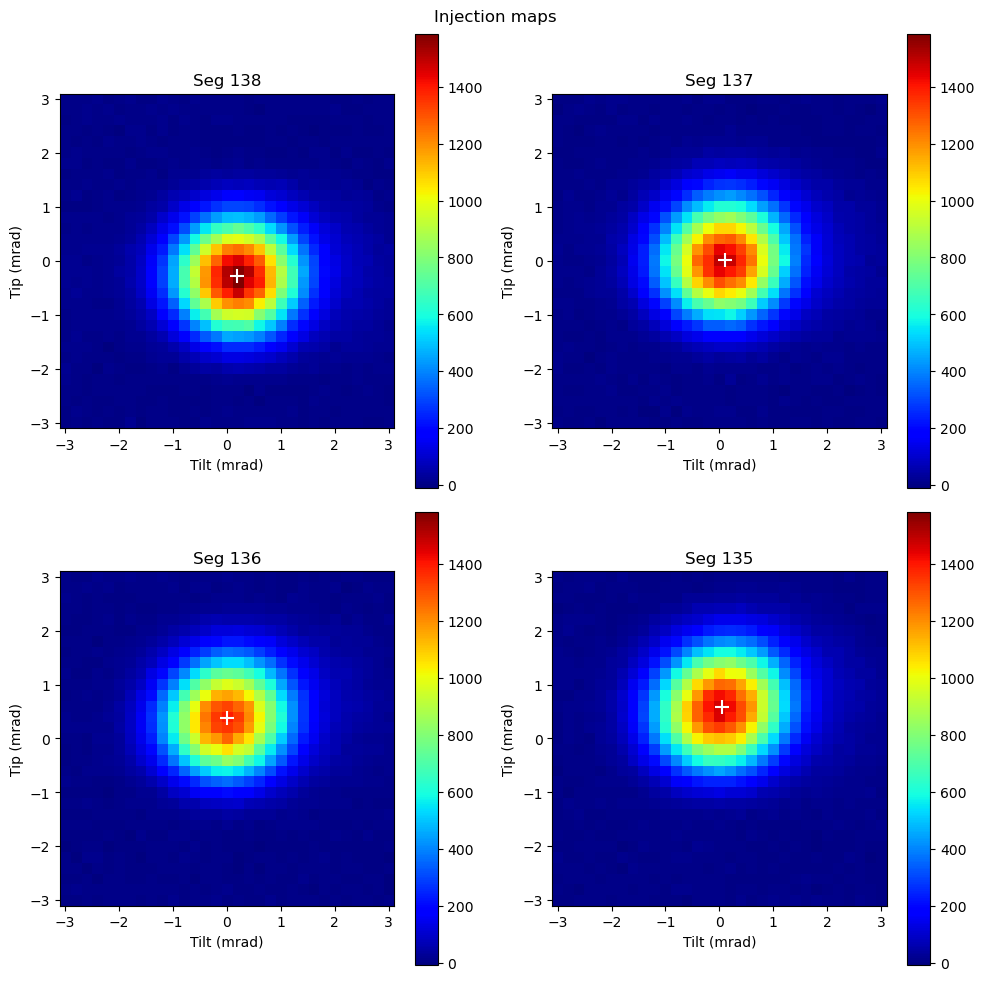

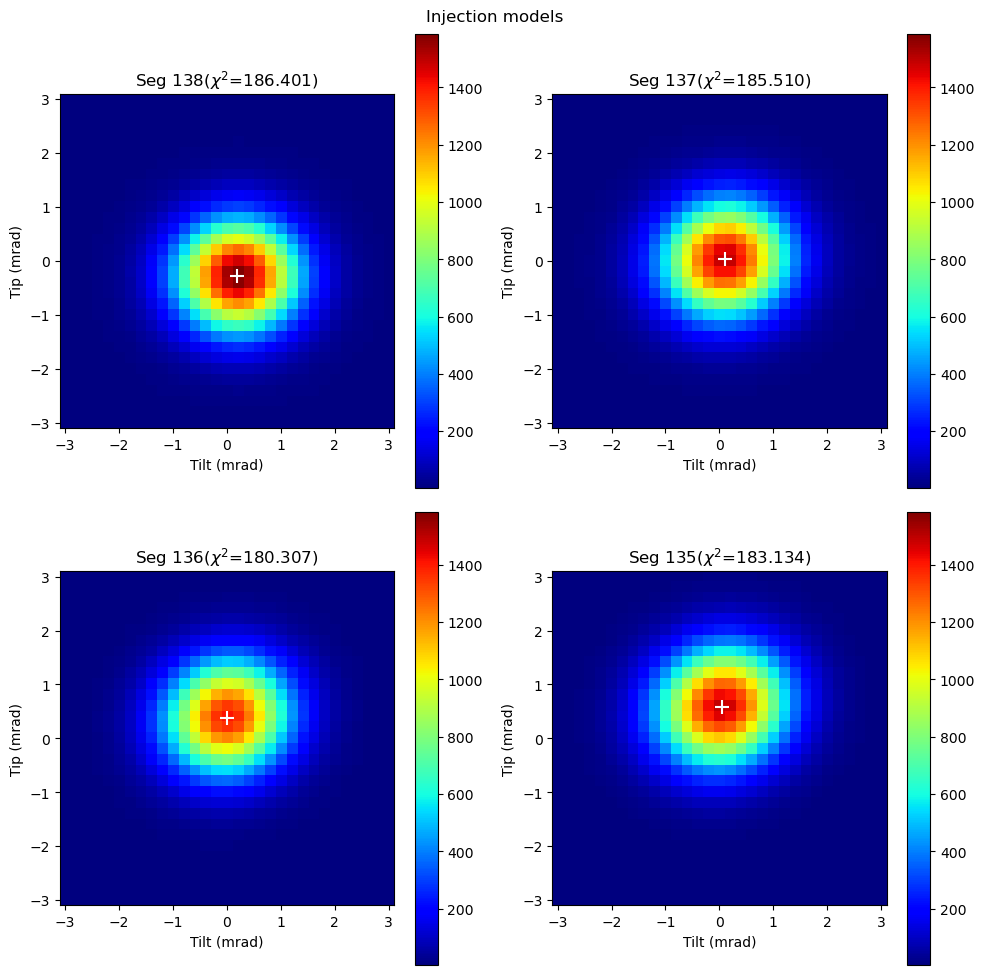

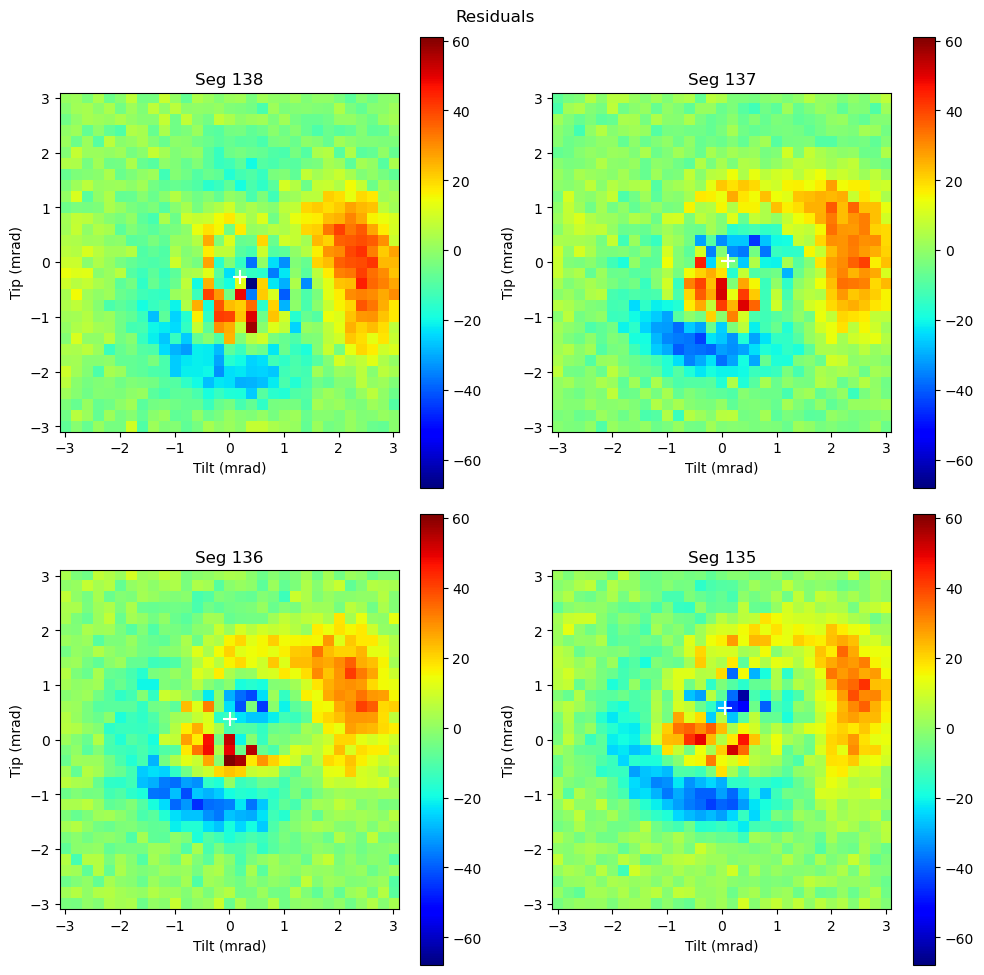

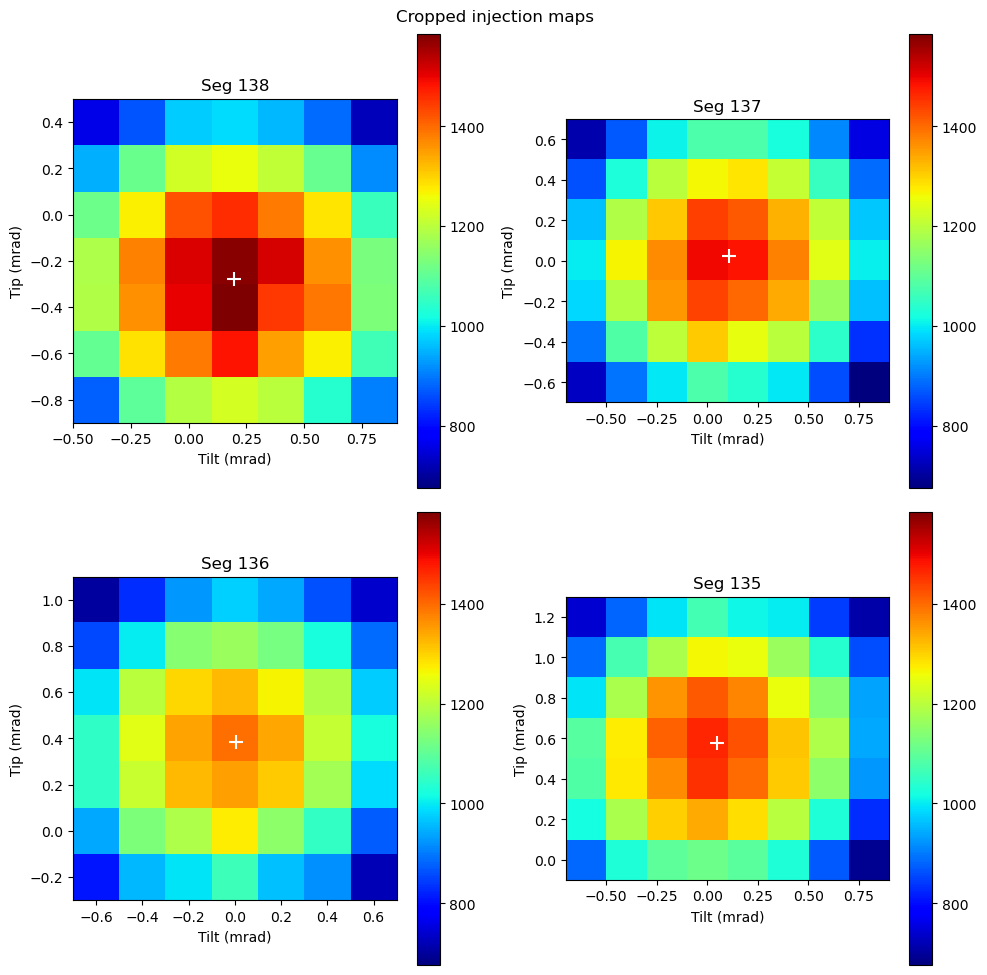

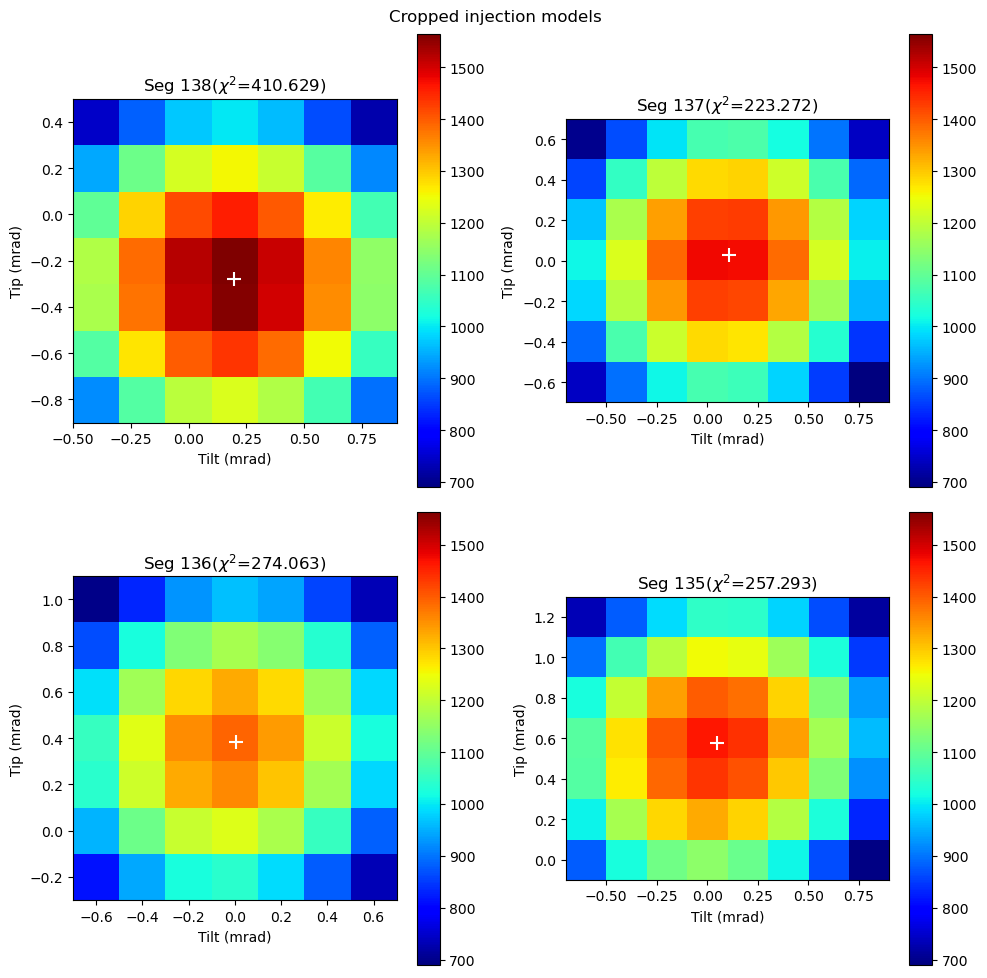

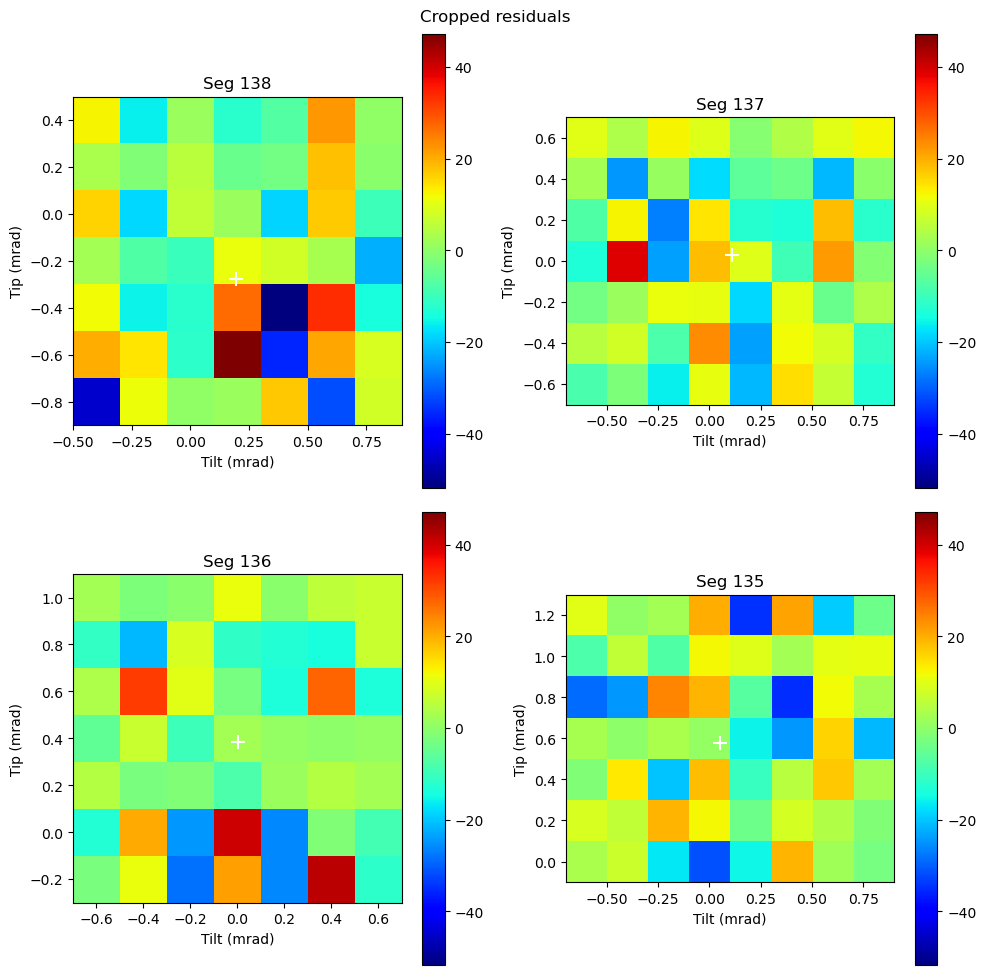

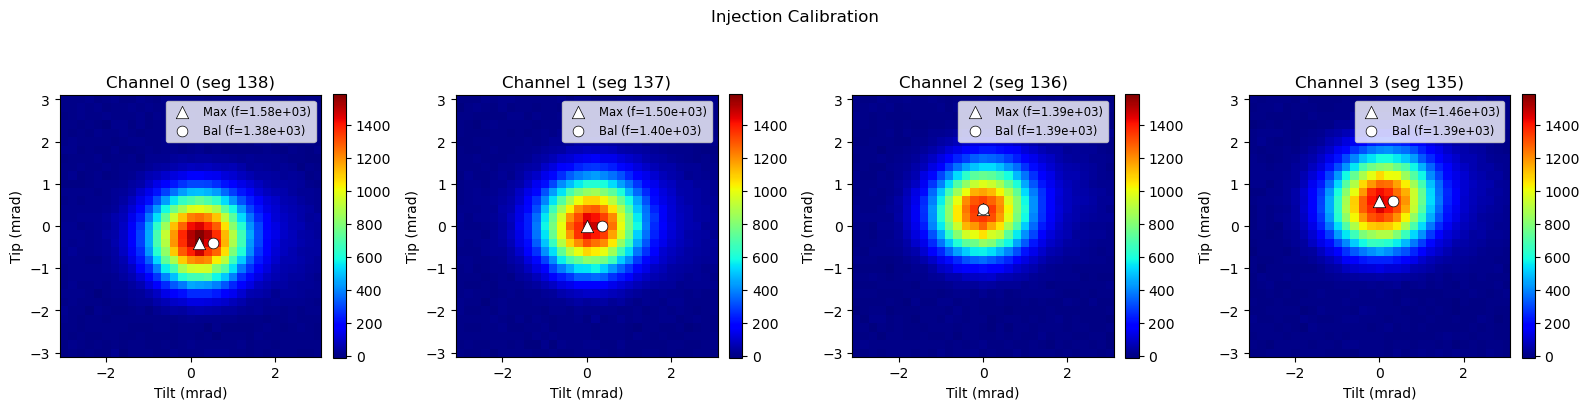

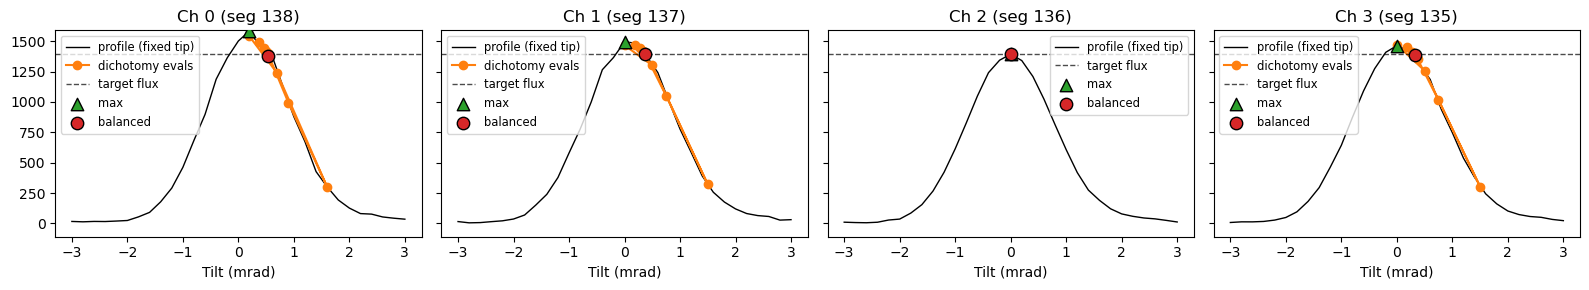

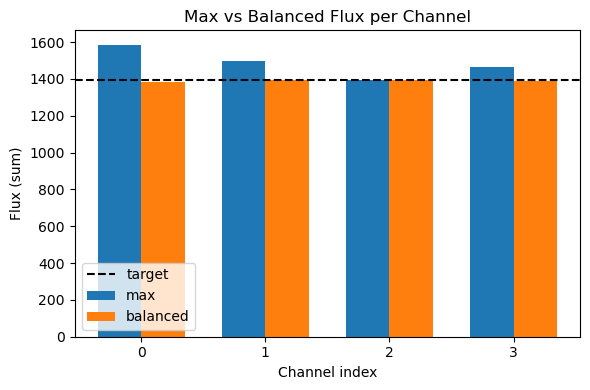

Successfully saved in FITS
Injection ZERO on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


In [5]:
# Injection calibration
avg_frame = 1
avg_frames_bal = 5
out_inj = inj.calibrate(verbose=True, plot=True, save_path=path, 
                        avg_frames=avg_frame, avg_frames_bal=avg_frames_bal,
                        tilt_tol = 0.5e-3, no_balancing=False)

inj.zero()

# Spectral calibration : Acquisition

In [6]:
inj.set_balanced()

Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


In [7]:
nframes = 10
crop_mode = 'rectangles'
lambdas = [1530, 1540, 1550, 1560]

## Take dark

In [ ]:
dark = cam.get_outputs(stack=nframes, crop_mode=crop_mode)
np.save(path / f'spec_cal_dark.npy', dark)
print('Data saved in', path / f'spec_cal_data_dark.npy')

Data saved in /mnt/disk1/archive/2026-06-10_5ad8eba/4_spectral_calibration/spec_cal_dark.npy


## Set tunable laser on 1st wavelength (channel 90, offset -7.220 GHz)

✅ Cred3 reset to configuration defaults.


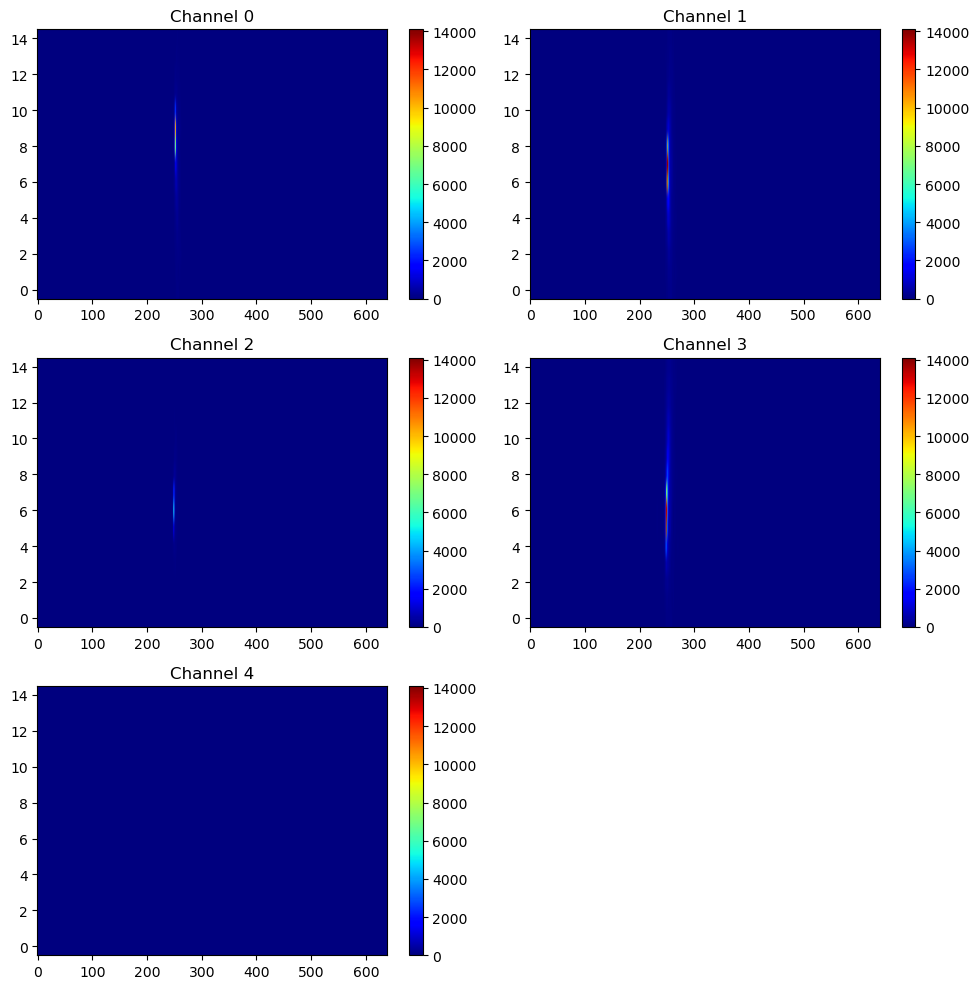

Data saved in /mnt/disk1/archive/2026-06-10_5ad8eba/4_spectral_calibration/spec_cal_data1530nm.npy


In [13]:
# check cropping
phobos.Config().reload()
cam.reset()
cam.check_cropping(crop_mode=crop_mode)
# Get data
flux = cam.get_outputs(stack=nframes, crop_mode=crop_mode)
save_data(path, f'spec_cal_data{lambdas[0]}nm.npy', flux)

## Set tunable laser on 2nd wavelength (channel 64, offset +20.426 GHz)

✅ Cred3 reset to configuration defaults.


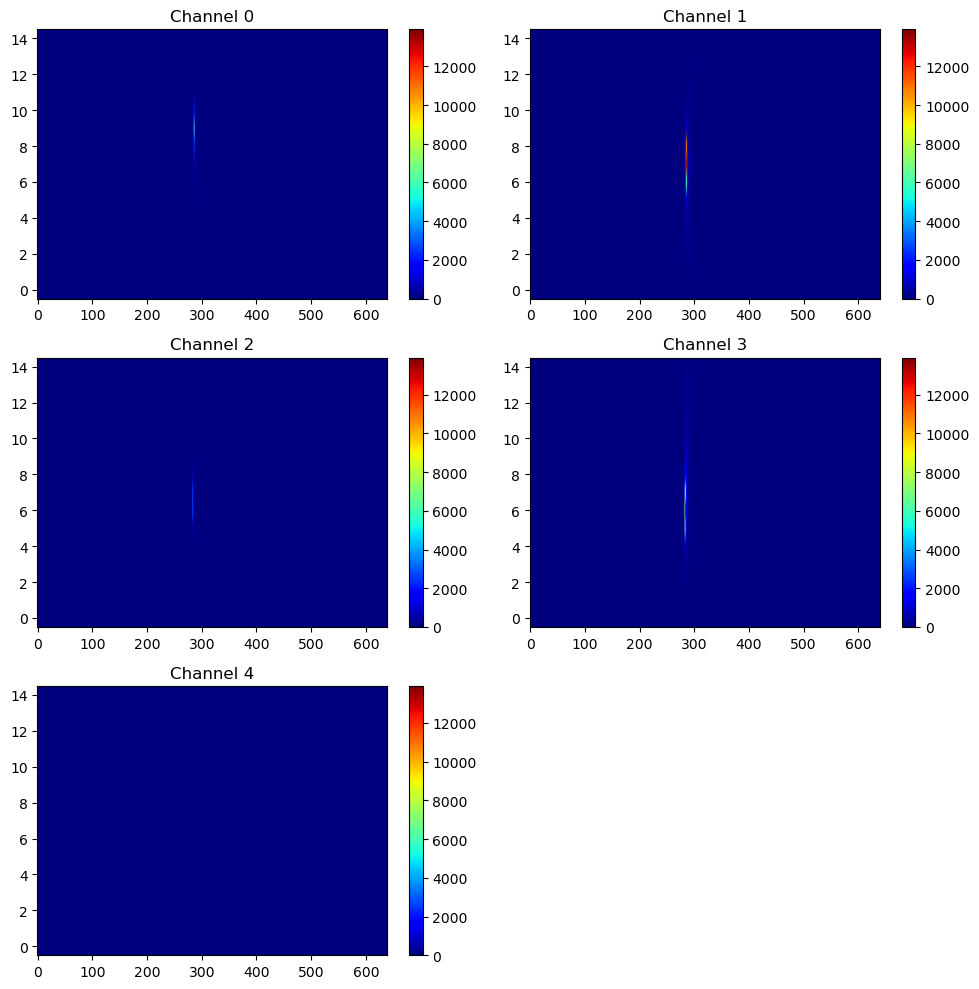

Data saved in /mnt/disk1/archive/2026-06-10_5ad8eba/4_spectral_calibration/spec_cal_data1540nm.npy


In [36]:
# check cropping
phobos.Config().reload()
cam.reset()
cam.check_cropping(crop_mode=crop_mode)
# Get data
flux = cam.get_outputs(stack=nframes, crop_mode=crop_mode)
save_data(path, f'spec_cal_data{lambdas[1]}nm.npy', flux)

## Set tunable laser on 3rd wavelength (channel 39, offset +14.486 GHz)

✅ Cred3 reset to configuration defaults.


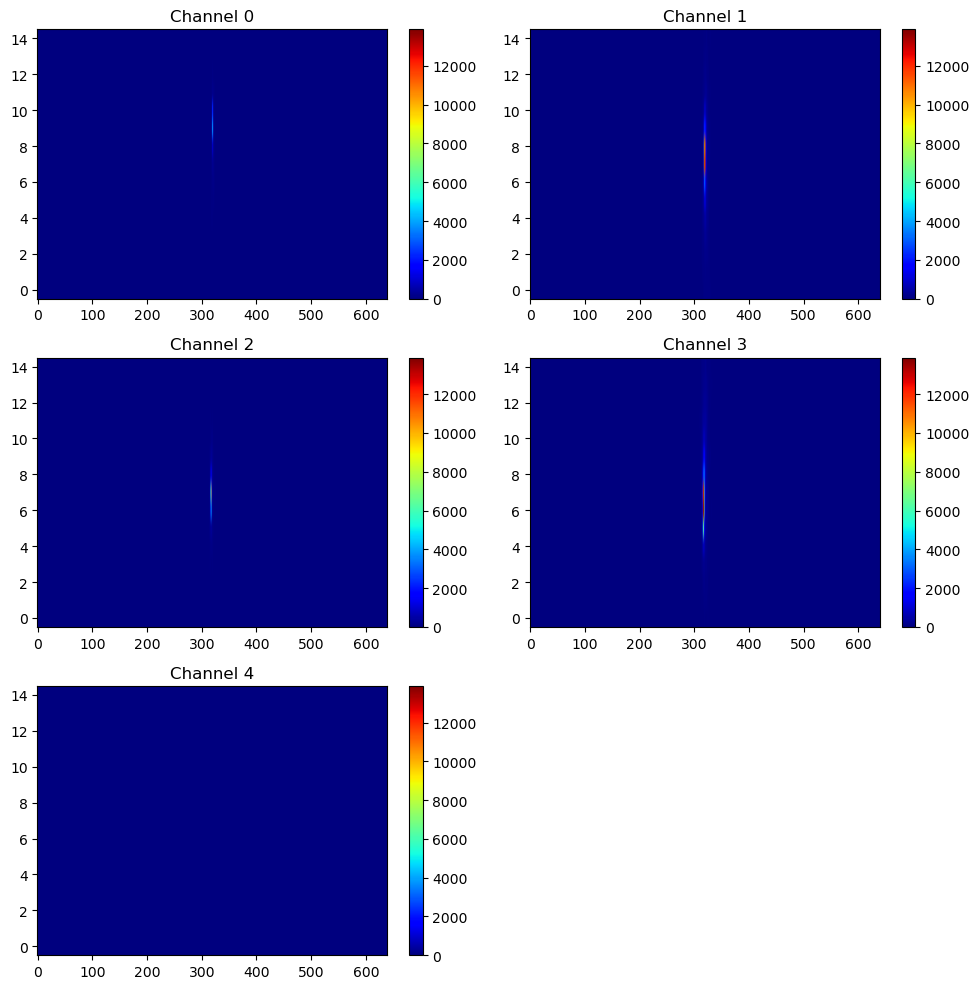

Data saved in /mnt/disk1/archive/2026-06-10_5ad8eba/4_spectral_calibration/spec_cal_data1550nm.npy


In [15]:
# check cropping
phobos.Config().reload()
cam.reset()
cam.check_cropping(crop_mode=crop_mode)
# Get data
flux = cam.get_outputs(stack=nframes, crop_mode=crop_mode)
save_data(path, f'spec_cal_data{lambdas[2]}nm.npy', flux)

## Set tunable laser on 4th wavelength (channel 14, offset +24.650 GHz)

✅ Cred3 reset to configuration defaults.


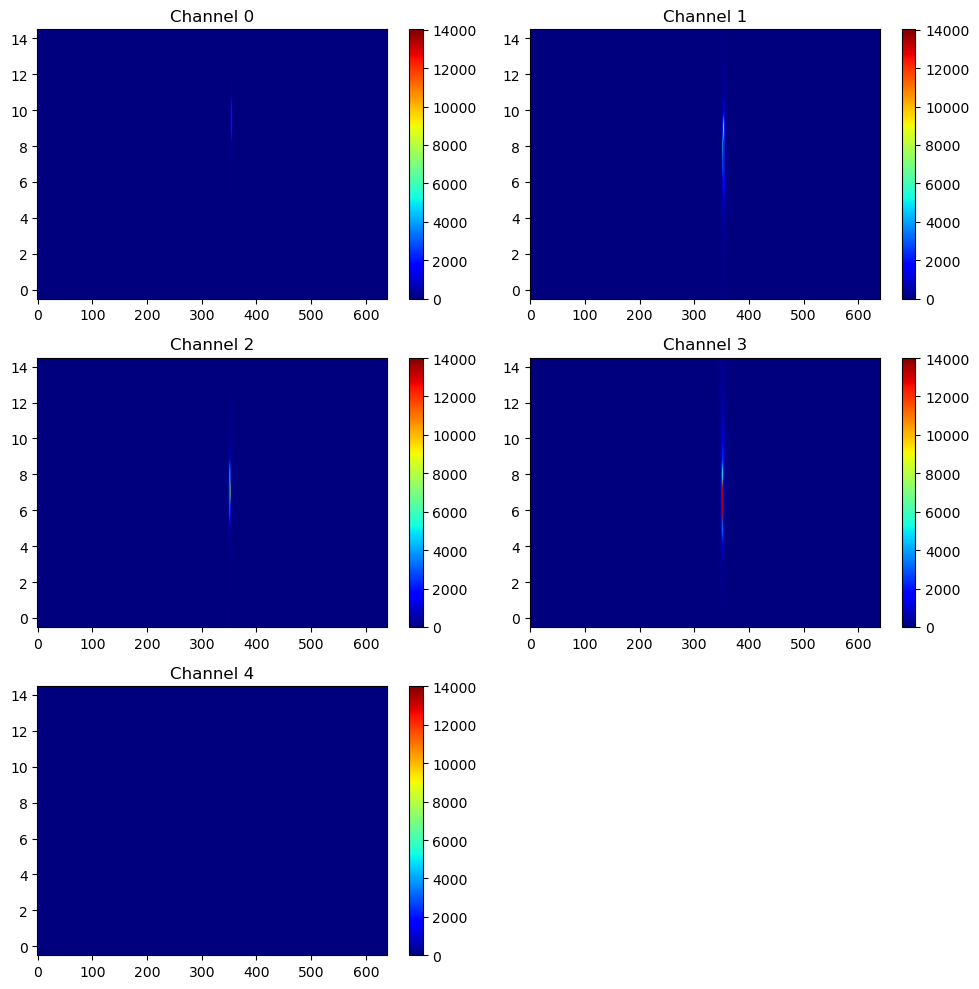

Data saved in /mnt/disk1/archive/2026-06-10_5ad8eba/4_spectral_calibration/spec_cal_data1560nm.npy


In [40]:
# check cropping
phobos.Config().reload()
cam.reset()
cam.check_cropping(crop_mode=crop_mode)
# Get data
flux = cam.get_outputs(stack=nframes, crop_mode=crop_mode)
save_data(path, f'spec_cal_data{lambdas[3]}nm.npy', flux)

# Spectral calibration : Analysis

In [17]:
from scipy.special import erf

def skewed_gaussian(
    x: np.ndarray,
    amplitude: float = 1.0,
    center: float = 0.0,
    sigma: float = 1.0,
    gamma: float = 0.0,
) -> np.ndarray:
    """Evaluate a skewed Gaussian profile.

    The profile is a Gaussian modulated by an error-function term, using the
    same parametrisation as ``lmfit.models.SkewedGaussianModel``.

    Parameters
    ----------
    x : ndarray
        Independent variable (e.g. wavelength or pixel position).
    amplitude : float, optional
        Overall amplitude (area-related scaling). Default is 1.0.
    center : float, optional
        Center of the unskewed Gaussian. Default is 0.0.
    sigma : float, optional
        Standard deviation of the Gaussian (must be > 0). Default is 1.0.
    gamma : float, optional
        Skewness parameter. ``gamma = 0`` yields a symmetric Gaussian;
        positive values skew right, negative values skew left. Default is 0.0.

    Returns
    -------
    ndarray
        Skewed Gaussian evaluated at ``x``, same shape as ``x``.

    Examples
    --------
    >>> import numpy as np
    >>> x = np.linspace(1520, 1570, 200)
    >>> y = skewed_gaussian(x, amplitude=1.0, center=1550, sigma=5.0, gamma=2.0)
    >>> y.shape
    (200,)
    """
    if sigma <= 0:
        raise ValueError("sigma must be strictly positive")

    x = np.asarray(x, dtype=float)

    gaussian = (amplitude / (sigma * np.sqrt(2.0 * np.pi))) * np.exp(
        -((x - center) ** 2) / (2.0 * sigma ** 2)
    )
    skew = 1.0 + erf(gamma * (x - center) / (sigma * np.sqrt(2.0)))

    return gaussian * skew

def skewed_gaussian_with_ramp(
    x: np.ndarray,
    amplitude: float = 1.0,
    center: float = 0.0,
    sigma: float = 1.0,
    gamma: float = 0.0,
    offset: float = 0.0,
    slope: float = 0.0,
) -> np.ndarray:
    """Evaluate a skewed Gaussian profile on top of a linear ramp.

    The model is the sum of a skewed Gaussian (see :func:`skewed_gaussian`)
    and a linear baseline ``offset + slope * x``. This is useful to fit a
    spectral peak sitting on a sloped background.

    Parameters
    ----------
    x : ndarray
        Independent variable (e.g. wavelength or pixel position).
    amplitude : float, optional
        Overall amplitude of the skewed Gaussian. Default is 1.0.
    center : float, optional
        Center of the unskewed Gaussian. Default is 0.0.
    sigma : float, optional
        Standard deviation of the Gaussian (must be > 0). Default is 1.0.
    gamma : float, optional
        Skewness parameter. ``gamma = 0`` yields a symmetric Gaussian;
        positive values skew right, negative values skew left. Default is 0.0.
    offset : float, optional
        Constant baseline value (intercept of the ramp). Default is 0.0.
    slope : float, optional
        Slope of the linear baseline. Default is 0.0.

    Returns
    -------
    ndarray
        Skewed Gaussian plus linear ramp evaluated at ``x``, same shape as ``x``.

    Examples
    --------
    >>> import numpy as np
    >>> x = np.linspace(1520, 1570, 200)
    >>> y = skewed_gaussian_with_ramp(
    ...     x, amplitude=1.0, center=1550, sigma=5.0,
    ...     gamma=2.0, offset=0.1, slope=0.002,
    ... )
    >>> y.shape
    (200,)
    """
    x = np.asarray(x, dtype=float)

    peak = skewed_gaussian(x, amplitude=amplitude, center=center,
                           sigma=sigma, gamma=gamma)
    ramp = offset + slope * x

    return peak + ramp

## Find peaks

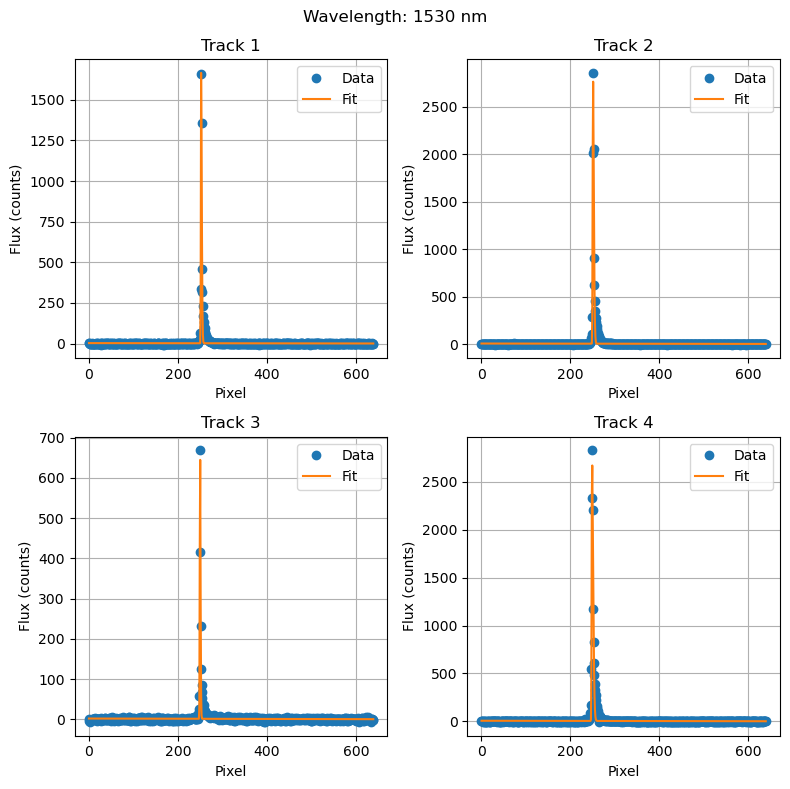

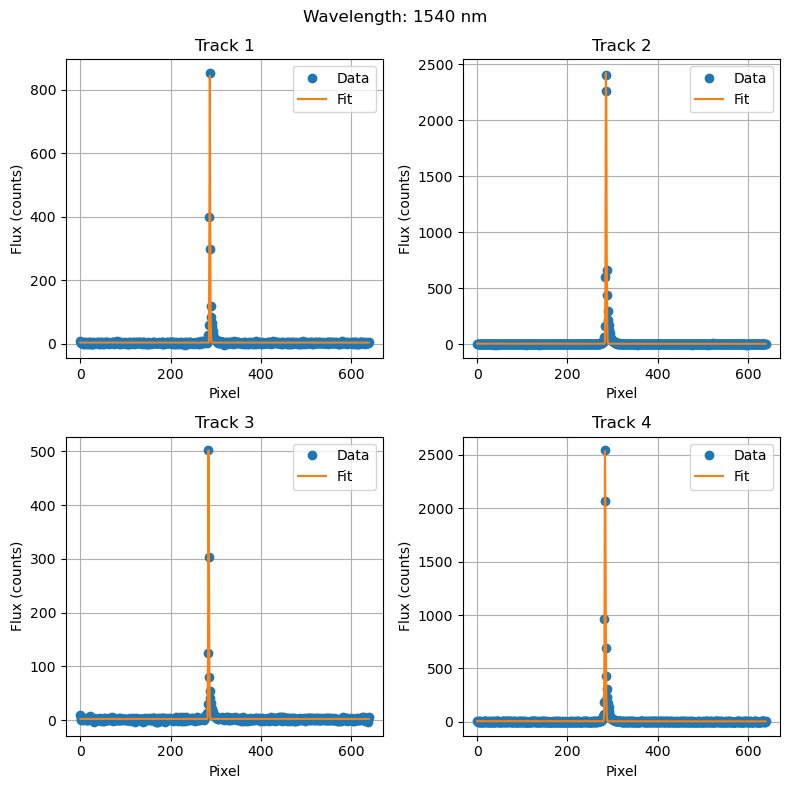

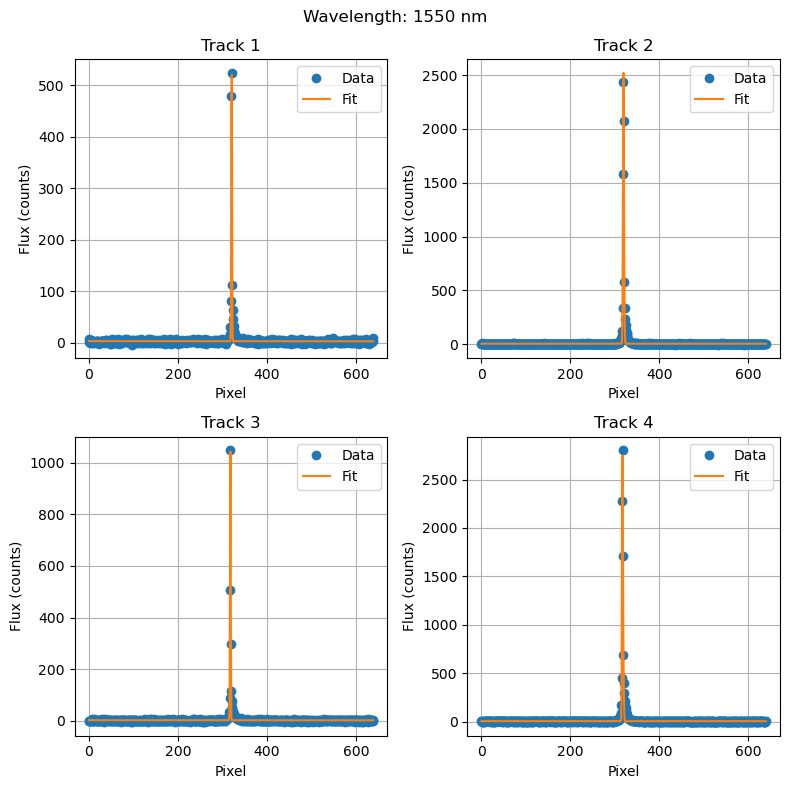

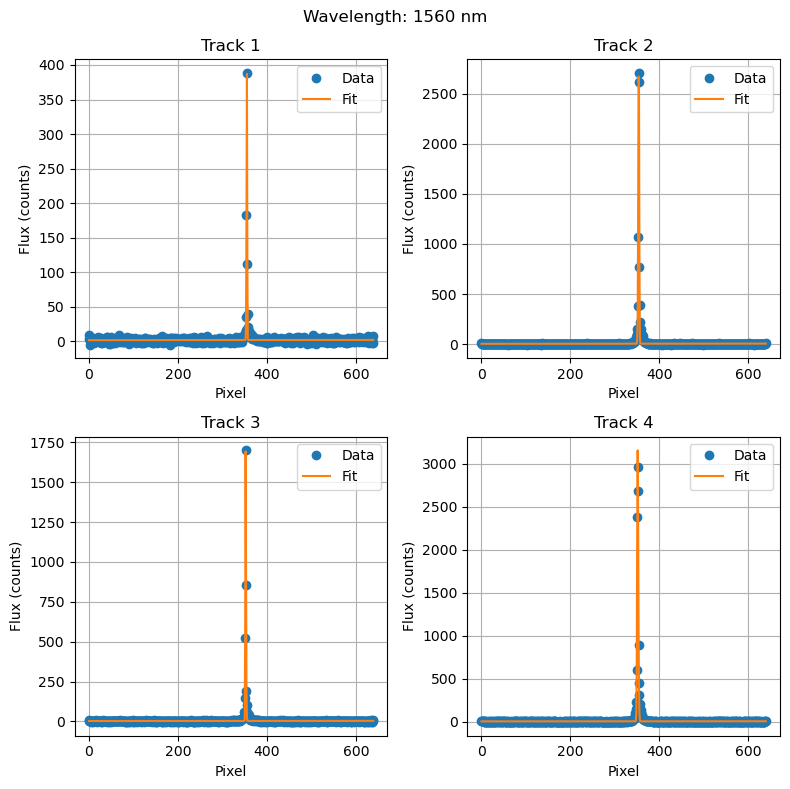

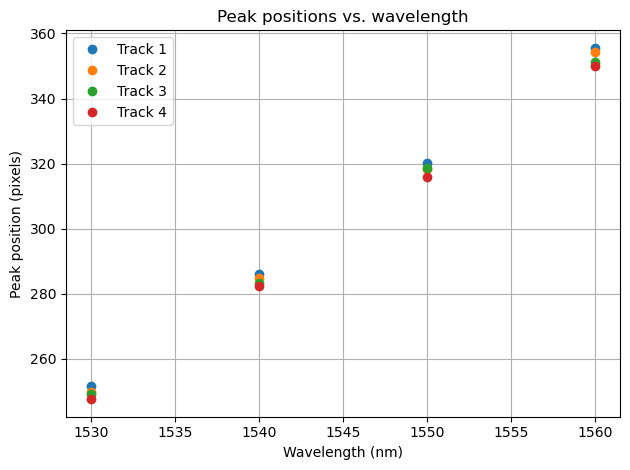

In [55]:
peaks = []
n_roi = 4


for wl in lambdas:
    fluxes = np.load(path / f'spec_cal_data{wl}nm.npy')
    x = np.arange(fluxes.shape[1])
    temp = []

    plt.figure(figsize=(8,8))
    plt.suptitle(f'Wavelength: {wl} nm')
    for i in range(n_roi):
        plt.subplot(2,2,i+1)
        flux = fluxes[i]
        popt, _ = curve_fit(skewed_gaussian_with_ramp, x, flux, 
                            p0=[flux.max(), x[np.argmax(flux)], 1.0, 0.0, np.median(flux), 0.0],
                            bounds=([0, x.min(), 0, -np.inf, -flux.max(), -np.inf], [np.inf, x.max(), np.inf, np.inf, flux.max(), np.inf]))
        temp.append(popt[1])
        plt.plot(x, flux, 'o', label='Data')
        plt.plot(x, skewed_gaussian_with_ramp(x, *popt), label='Fit')
        plt.title(f'Track {i+1}')
        plt.xlabel('Pixel')
        plt.ylabel('Flux (counts)')
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    peaks.append(temp)

peaks = np.array(peaks) # (wavelength, track)

# %matplotlib widget
plt.figure()
plt.plot(lambdas, peaks, 'o')
plt.grid()
plt.legend([f'Track {i+1}' for i in range(peaks.shape[1])], loc='best')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Peak position (pixels)')
plt.title('Peak positions vs. wavelength')
plt.tight_layout()

## Get spectral calibration

Calibration coefficients (slope, intercept):
[[2.88585770e-01 1.45748067e+03]
 [2.88151178e-01 1.45804418e+03]
 [2.92259260e-01 1.45715824e+03]
 [2.93171576e-01 1.45736093e+03]]
Data saved in /mnt/disk1/archive/2026-06-10_5ad8eba/4_spectral_calibration/spec_cal_coeffs.npy
Track  | Spectral resolution (nm/px) | Spectral range (nm)
---------------------------------------------------------
1      |                       0.289 |             184.41
2      |                       0.288 |             184.13
3      |                       0.292 |             186.75
4      |                       0.293 |             187.34


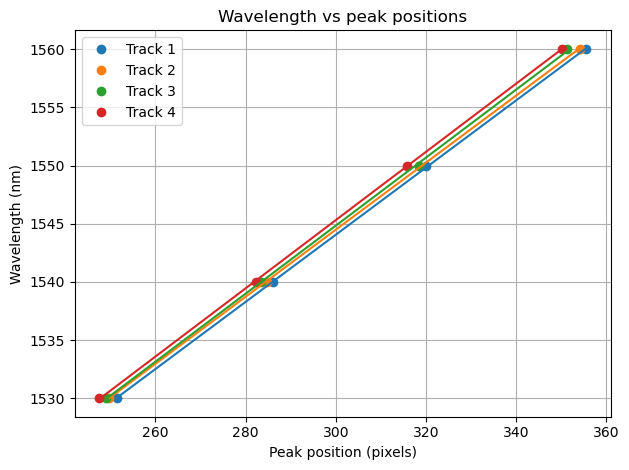

In [75]:
coeffs = [np.polyfit(peaks[:,i], lambdas, deg=1) for i in range(peaks.shape[1])]
coeffs = np.array(coeffs)
print('Calibration coefficients (slope, intercept):')
print(coeffs)
save_data(path, 'spec_cal_coeffs.npy', coeffs)

fig, ax = plt.subplots()
data_lines = ax.plot(peaks, lambdas, 'o')
ax.set_prop_cycle(None)
[ax.plot(peaks[:,i], np.polyval(coeffs[i], peaks[:,i]), '-') for i in range(peaks.shape[1])]
ax.grid()
ax.legend(data_lines, [f'Track {i+1}' for i in range(peaks.shape[1])], loc='best')
ax.set_ylabel('Wavelength (nm)')
ax.set_xlabel('Peak position (pixels)')
ax.set_title('Wavelength vs peak positions')
plt.tight_layout()

# Print calibration results as a formatted table
header = ("Track", "Spectral resolution (nm/px)", "Spectral range (nm)")
row_fmt = "{:<6} | {:>27} | {:>18}"
sep = "-" * (6 + 3 + 27 + 3 + 18)

print(row_fmt.format(*header))
print(sep)
for i in range(n_roi):
    slope = float(coeffs[i, 0])            # slope (nm/px)
    spectral_range = float(np.polyval(coeffs[i], 639) - np.polyval(coeffs[i], 0))
    print(row_fmt.format(f"{i+1}", f"{slope:.3f}", f"{spectral_range:.2f}"))



# The end

In [76]:
print('Path is', path)
inj.zero()

Path is /mnt/disk1/archive/2026-06-10_5ad8eba/4_spectral_calibration
Injection ZERO on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
